# Sentiment analysis on movie reviews

In this notebook, we will explore basic NLP techniques to analyze movie reviews using the Large Movie Review Dataset, found in: https://ai.stanford.edu/~amaas/data/sentiment/

In [1]:
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import os

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import re

In [2]:
def load_imdb_data(path):
    data = []
    labels = []
    for label in ['pos', 'neg']:
        dir_path = f"{path}/{label}"
        for filename in os.listdir(dir_path):
            with open(f"{dir_path}/{filename}", 'r', encoding='utf-8') as file:
                data.append(file.read())
                labels.append(1 if label == 'pos' else 0)
    return pd.DataFrame({'review': data, 'sentiment': labels})

In [3]:
# Change this to the path where you unzipped the dataset
dataset_root = "../data/aclImdb"

train_df = load_imdb_data(dataset_root + "/train")
test_df = load_imdb_data(dataset_root + "/test")

## EDA

Let's take a quick look at the data to understand the distribution of sentiments, the length of reviews, and some common words used in positive vs negative reviews.

<Axes: xlabel='sentiment', ylabel='count'>

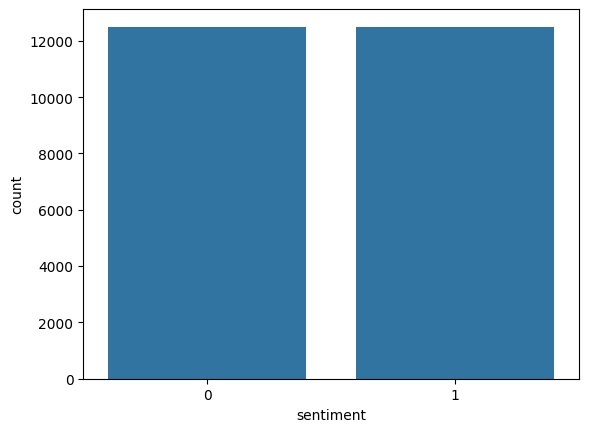

In [4]:
sns.countplot(x='sentiment', data=train_df)

As we can see, the dataset is balanced with an equal number of positive and negative reviews.

Let's now look at the distribution of review lengths. First compute the length of each review, both in terms of characters and words, and then plot the distributions.

In [5]:
n_chars = train_df['review'].apply(len)
n_words = train_df['review'].apply(lambda s: len(s.split()))

review_length_df = pd.DataFrame({'chars': n_chars, 'words': n_words, 'sentiment': train_df['sentiment']})
review_length_df.describe().T

,count,mean,std,min,25%,50%,75%,max
chars,25000.0,1325.06964,1003.133670,52.0,702.0,979.0,1614.0,13704.0
words,25000.0,233.78720,173.733032,10.0,127.0,174.0,284.0,2470.0
sentiment,25000.0,0.50000,0.500010,0.0,0.0,0.5,1.0,1.0


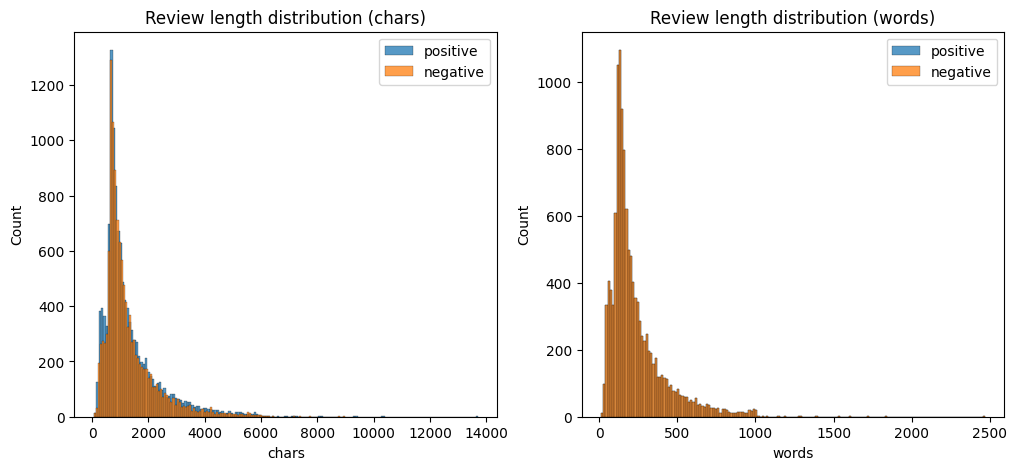

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['chars'], ax=axs[0], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 0]['chars'], ax=axs[0], label='negative')
axs[0].set_title("Review length distribution (chars)")
axs[0].legend()

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='negative')
axs[1].set_title("Review length distribution (words)")
axs[1].legend()

As can be seen, the distribution of review lengths is quite similar for both positive and negative reviews, with most reviews being below 500 words. In terms of characters, most reviews have less than 3000 characters. This can be confirmed with boxplots, which show the "whiskers" of the distribution and any potential outliers.

Text(0.5, 1.0, 'Review length (words) by sentiment')

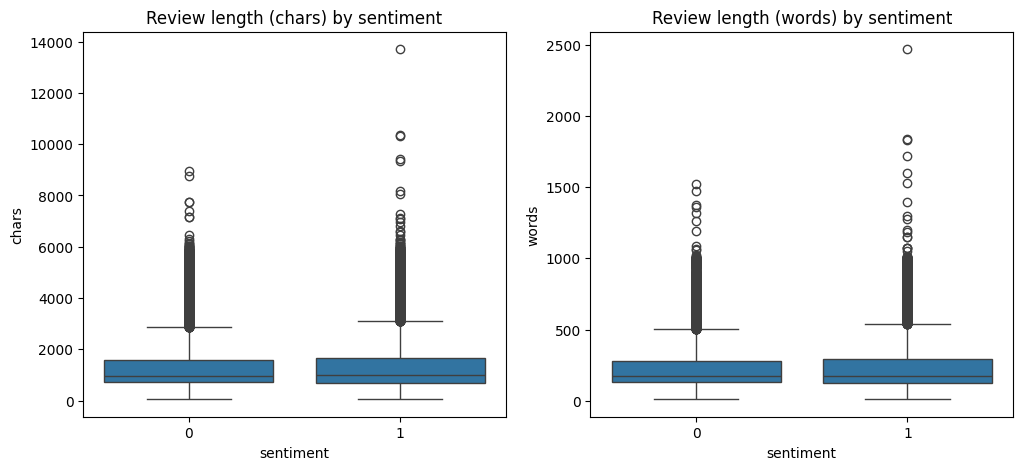

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='sentiment', y='chars', data=review_length_df, ax=axs[0])
axs[0].set_title("Review length (chars) by sentiment")

sns.boxplot(x='sentiment', y='words', data=review_length_df, ax=axs[1])
axs[1].set_title("Review length (words) by sentiment")

In [8]:
def get_top_words(docs, n=20):
    all_words = ' '.join(docs).split()
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [9]:
print("Top words in positive reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 1]['review']))

print("\nTop words in negative reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 0]['review']))

Top words in positive reviews:
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'that', 'I', 'it', 'this', '/><br', 'as', 'with', 'was', 'for', 'The', 'but', 'his', 'on']

Top words in negative reviews:
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'I', 'that', 'this', 'it', '/><br', 'was', 'for', 'with', 'as', 'but', 'movie', 'The', 'on']


As we can see, the most common words in both positive and negative reviews are quite similar, with words like "the", "and", "a", "is" appearing frequently. Another issue is that this is case-insensitive, so "the" is treated as different that "The". To get a better idea of common words by sentiment, we can normalize the text by converting it to lowercase and removing any punctuation (and numbers, while we are at it).

In [10]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [11]:
print("Top words in positive reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']]))

print("\nTop words in negative reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']]))

Top words in positive reviews (normalized):
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'br', 'as', 'with', 'for', 'was', 'but', 'film', 'movie', 'his']

Top words in negative reviews (normalized):
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'this', 'i', 'it', 'that', 'br', 'was', 'movie', 'for', 'but', 'with', 'as', 'film', 'on']


While most of the common words are still common stop words, at least we are now getting words like "movie" and "film". However, this still doesn't give us a good idea of which words are more associated with positive vs negative reviews.

To deal with this, we will use the NLTK library to remove stop words.

In [12]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fiona\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
stopwords = stopwords.words('english')
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Some of these words are negations, such as "not", "no", "nor", which can be important for sentiment analysis. We will keep these in our list of stop words.

In [14]:
neg_words = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

stopwords = [w for w in stopwords if w not in neg_words]

Let's redefine our `get_top_words` function to remove stop words before counting the most common words.

In [15]:
def get_top_words(docs, n=20, exclude=None):
    all_words = ' '.join(docs).split()
    if exclude is not None:
        all_words = [w for w in all_words if w not in exclude]
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [16]:
# Ensure stopwords are processed in the same way as our documents (lowercased and punctuation removed)
norm_stopwords = set([normalize_text(w) for w in stopwords])

print("Top words in positive reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']], exclude=norm_stopwords))

print("\nTop words in negative reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']], exclude=norm_stopwords))

Top words in positive reviews (no stopwords):
['br', 'film', 'movie', 'not', 'one', 'like', 'good', 'story', 'great', 'time', 'see', 'also', 'really', 'would', 'even', 'first', 'much', 'no', 'people', 'films']

Top words in negative reviews (no stopwords):
['br', 'movie', 'film', 'not', 'one', 'like', 'no', 'even', 'good', 'bad', 'would', 'really', 'time', 'see', 'dont', 'get', 'much', 'story', 'people', 'could']


We can now start to see some differences in the most common words between positive and negative reviews. Words like "good" and "great" are more common in positive reviews, while words like "bad" are now more common in negative reviews. That said, there is still a lot of overlap, since words like "movie", "film" and "story" are expected to appear in movie reviews regardless of the sentiment. We will deal with this later.

## Vectorization

We have now done some basic EDA to understand the data. The next step is to convert the text data into a format that can be used for machine learning models. One common approach is to use a bag-of-words representation, where we create a vector for each document that counts the occurrences of each word in the vocabulary. We can use the `CountVectorizer` from the `sklearn` library to do this.

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stopwords, lowercase=True)
x_train = vectorizer.fit_transform(train_df['review'])
x_test = vectorizer.transform(test_df['review'])

Now that we vectorized our text data, let's compare the result with the original text.

In [18]:
print(train_df['review'][0])
print(x_train[0])

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 58 stored elements and shape (1, 74726)>
  Coords	Values
  (0, 9230)	4
  (0, 30858)	5
  (0, 10826)	1
  (0, 13474)	1
  (0, 53350)	1
  

We can see that the vectorizer converts every review into a sparse vector of word counts, where the length of the vector is equal to the size of the vocabulary (the number of unique words in the training set after removing stop words). The `fit_transform` method learns the vocabulary from the training data and transforms it into vectors, while the `transform` method uses the same vocabulary to transform the test data.

Each element in the vector corresponds to a word in the vocabulary, and the value of that element is the count of how many times that word appears in the review. Since most reviews will only contain a small subset of the total vocabulary, these vectors are typically very sparse (mostly zeros), which is why they are stored in a sparse format.

Let's get the list of words that are present in the first review and their corresponding counts.

In [19]:
vec = x_train[0].toarray()[0].tolist()
word_count = [(idx, count) for idx, count in enumerate(vec) if count > 0]
print(word_count)

[(646, 1), (1917, 1), (2150, 1), (6702, 1), (9230, 4), (9744, 1), (10826, 1), (12652, 1), (12911, 1), (13474, 1), (22187, 1), (23093, 1), (23754, 1), (24297, 1), (24591, 1), (30858, 5), (32680, 1), (33770, 1), (33811, 1), (34592, 1), (36809, 1), (38022, 1), (38627, 1), (38815, 1), (40771, 1), (44180, 1), (46864, 1), (48620, 1), (49455, 1), (50078, 1), (50671, 1), (51797, 1), (51856, 1), (53350, 1), (53748, 1), (53885, 1), (54710, 1), (54872, 1), (55749, 1), (56943, 1), (57502, 1), (57614, 1), (57947, 2), (57968, 1), (58140, 1), (58506, 1), (60414, 1), (63684, 2), (63685, 2), (64599, 1), (65664, 4), (65666, 1), (66431, 1), (66827, 1), (68045, 1), (72437, 1), (72797, 1), (74040, 1)]


The previous cell gives us a list of tuples, where each tuple contains the index of a word in the vocabulary and the count of that word in the first review. To get the actual words, we can use the `get_feature_names_out` method of the vectorizer to get the list of words in the vocabulary and then map the indices to words.

In [20]:
for idx, count in word_count:
    print(f"{vectorizer.get_feature_names_out()[idx]}: {count}")

35: 1
adults: 1
age: 1
believe: 1
bromwell: 4
burn: 1
cartoon: 1
classic: 1
closer: 1
comedy: 1
episode: 1
expect: 1
far: 1
fetched: 1
financially: 1
high: 5
immediately: 1
insightful: 1
inspector: 1
isn: 1
knew: 1
lead: 1
life: 1
line: 1
many: 1
much: 1
one: 1
pathetic: 1
pettiness: 1
pity: 1
pomp: 1
profession: 1
programs: 1
ran: 1
reality: 1
recalled: 1
remind: 1
repeatedly: 1
right: 1
sack: 1
satire: 1
saw: 1
school: 2
schools: 1
scramble: 1
see: 1
situation: 1
student: 2
students: 2
survive: 1
teachers: 4
teaching: 1
think: 1
time: 1
tried: 1
welcome: 1
whole: 1
years: 1


One problem with CountVectorizer is that it gives equal weight to all words, regardless of how common they are across the entire corpus. This can lead to issues where very common words (like "movie", "film", "story") dominate the representation, even though they may not be very informative for distinguishing between positive and negative reviews. To address this, we can use the `TfidfVectorizer`, which stands for Term Frequency-Inverse Document Frequency. This vectorizer gives more weight to words that are more unique to a particular document and less weight to words that are common across all documents.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords, lowercase=True)
x_train_tfidf = tfidf_vectorizer.fit_transform(train_df['review'])
x_test_tfidf = tfidf_vectorizer.transform(test_df['review'])

Now let's compare the TF-IDF representation with the original text and the CountVectorizer representation.

In [22]:
review_no_stopwords = ' '.join([w for w in train_df['review'][1].split() if w.lower() not in stopwords])
print("Original review:\n", train_df['review'][1])

print("\nOriginal review (no stopwords):\n", review_no_stopwords)

print("\nAs token IDs:\n", [vectorizer.vocabulary_.get(w.lower(), "-") for w in review_no_stopwords.split()])

Original review:
 Homelessness (or Houselessness as George Carlin stated) has been an issue for years but never a plan to help those on the street that were once considered human who did everything from going to school, work, or vote for the matter. Most people think of the homeless as just a lost cause while worrying about things such as racism, the war on Iraq, pressuring kids to succeed, technology, the elections, inflation, or worrying if they'll be next to end up on the streets.<br /><br />But what if you were given a bet to live on the streets for a month without the luxuries you once had from a home, the entertainment sets, a bathroom, pictures on the wall, a computer, and everything you once treasure to see what it's like to be homeless? That is Goddard Bolt's lesson.<br /><br />Mel Brooks (who directs) who stars as Bolt plays a rich man who has everything in the world until deciding to make a bet with a sissy rival (Jeffery Tambor) to see if he can live in the streets for thir

## Training a model

Let's train a simple logistic regression model for this dataset.

To compare models fairly, we will keep the exact same logistic regression hyperparameters across all runs. Since reviews are loaded with all positives first and all negatives after, we will shuffle train/test once before running experiments so quick spot-checks are easier to interpret.

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42

# Ensures dataset is shuffled
train_exp_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_exp_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


In [24]:
def run_experiment(vectorizer, preprocess_fn=None):
    train_text = train_exp_df['review']
    test_text = test_exp_df['review']

    if preprocess_fn is not None:
        train_text = train_text.apply(preprocess_fn)
        test_text = test_text.apply(preprocess_fn)

    x_train_vec = vectorizer.fit_transform(train_text)
    y_train = train_exp_df['sentiment']

    x_test_vec = vectorizer.transform(test_text)
    y_test = test_exp_df['sentiment']

    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    y_test_pred = model.predict(x_test_vec)
    y_train_pred = model.predict(x_train_vec)

    metrics = {
        'accuracy_train': accuracy_score(y_train, y_train_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
        'precision_train': precision_score(y_train, y_train_pred),
        'precision_test': precision_score(y_test, y_test_pred),
        'recall_train': recall_score(y_train, y_train_pred),
        'recall_test': recall_score(y_test, y_test_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'f1_test': f1_score(y_test, y_test_pred),
    }

    return model, vectorizer, metrics


In [25]:
experiments = [
    ('CountVectorizer', None, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-norm', normalize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer', None, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-norm', normalize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df


,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer,0.93652,0.88304,0.929950,0.883347,0.94416,0.88264,0.937001,0.882993
3,TfidfVectorizer-norm,0.93720,0.88224,0.931334,0.882730,0.94400,0.88160,0.937624,0.882165
1,CountVectorizer-norm,0.99892,0.86528,0.999040,0.871220,0.99880,0.85728,0.998920,0.864194
0,CountVectorizer,0.99832,0.86360,0.998480,0.869813,0.99816,0.85520,0.998320,0.862445


The table above compares all four configurations using the same logistic regression setup. You can use it to identify whether TF-IDF or CountVectorizer works better here, and whether applying `normalize_text` helps or hurts performance.



We can also look at the most important features for each model to see which words are driving the predictions. For logistic regression, we can look at the coefficients of the model to identify the most influential words for positive and negative sentiment.

As a reminder, a logistic regression model computes scores between 0 and 1 using a linear equation, where each feature has a coefficient. The higher the coefficient, the more that feature contributes to predicting the positive class (sentiment=1), while a lower coefficient contributes to predicting the negative class (sentiment=0). Since each feature represents a word in the vocabulary, we can look at the coefficients to see which words are most strongly associated with positive and negative reviews.

In [26]:
def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,refreshing (1.552),refreshing (1.626),great (7.241),great (7.296)
#2,wonderfully (1.494),wonderfully (1.455),excellent (6.169),excellent (6.250)
#3,funniest (1.350),funniest (1.376),best (5.193),best (5.278)
#4,superb (1.330),excellent (1.321),perfect (4.840),perfect (4.752)
#5,erotic (1.289),superb (1.308),wonderful (4.671),wonderful (4.648)
#6,excellent (1.282),erotic (1.307),well (4.447),well (4.209)
#7,perfect (1.272),flawless (1.278),amazing (4.227),favorite (4.190)
#8,surprisingly (1.252),perfect (1.220),love (4.059),amazing (4.172)
#9,carrey (1.244),hooked (1.216),favorite (4.057),love (4.104)



Top 10 negative words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,disappointment (-2.194),waste (-2.206),worst (-9.195),worst (-9.265)
#2,worst (-2.187),worst (-2.197),bad (-7.509),bad (-7.643)
#3,waste (-2.141),disappointment (-2.133),awful (-6.518),waste (-6.636)
#4,poorly (-1.792),poorly (-1.756),waste (-6.396),awful (-6.410)
#5,awful (-1.658),awful (-1.660),boring (-5.710),boring (-5.490)
#6,lacks (-1.612),lacks (-1.613),poor (-5.322),poor (-5.385)
#7,disappointing (-1.525),forgettable (-1.476),nothing (-4.839),nothing (-4.895)
#8,mess (-1.431),disappointing (-1.453),terrible (-4.783),terrible (-4.828)
#9,unfunny (-1.413),mstk (-1.444),worse (-4.662),worse (-4.702)


## Activity

#### Run 4 new experiments: 2 with CountVectorizer and 2 with TfidfVectorizer. For each vectorizer, apply stemming and lemmatization as the first step of your preprocessing function. Display the models metrics and top features as before.

In [27]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('wordnet')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_text(text):
    text = normalize_text(text)
    return ' '.join([stemmer.stem(w) for w in text.split()])

def lemma_text(text):
    text = normalize_text(text)
    return ' '.join([lemmatizer.lemmatize(w) for w in text.split()])

experiments2 = [
    ('CountVectorizer-stem', stem_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-lemma', lemma_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-stem', stem_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-lemma', lemma_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results2 = []
model_runs2 = []
for exp_name, preprocess_fn, vectorizer in experiments2:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results2.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs2.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df2 = pd.DataFrame(results2).sort_values('accuracy_test', ascending=False)
results_df2

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\fiona\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
3,TfidfVectorizer-lemma,0.93456,0.88084,0.928054,0.881114,0.94216,0.88048,0.935054,0.880797
2,TfidfVectorizer-stem,0.92900,0.87800,0.922144,0.877758,0.93712,0.87832,0.929572,0.878039
1,CountVectorizer-lemma,0.99844,0.85992,0.998639,0.866428,0.99824,0.85104,0.998440,0.858665
0,CountVectorizer-stem,0.99676,0.85536,0.997118,0.863562,0.99640,0.84408,0.996759,0.853710


In [28]:
print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs2, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs2, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer-stem,CountVectorizer-lemma,TfidfVectorizer-stem,TfidfVectorizer-lemma
rank,,,,
#1,refresh (1.711),refreshing (1.730),great (7.127),great (7.211)
#2,flawless (1.599),wonderfully (1.458),excel (6.569),excellent (6.294)
#3,driven (1.491),funniest (1.442),love (5.098),best (5.090)
#4,superb (1.445),flawless (1.428),enjoy (5.078),perfect (4.754)
#5,excel (1.437),superb (1.397),best (4.887),wonderful (4.663)
#6,squirrel (1.412),excellent (1.329),perfect (4.865),favorite (4.645)
#7,erot (1.397),carrey (1.297),favorit (4.614),well (4.275)
#8,funniest (1.336),whoopi (1.293),well (4.072),amazing (4.216)
#9,whoopi (1.271),erotic (1.234),beauti (4.008),loved (4.098)



Top 10 negative words across experiments


,CountVectorizer-stem,CountVectorizer-lemma,TfidfVectorizer-stem,TfidfVectorizer-lemma
rank,,,,
#1,worst (-2.036),worst (-2.143),worst (-8.940),worst (-9.245)
#2,poorli (-1.858),disappointment (-2.107),wast (-7.372),bad (-7.448)
#3,mstk (-1.763),waste (-2.083),bad (-7.163),waste (-6.673)
#4,aw (-1.726),poorly (-1.805),aw (-6.595),awful (-6.461)
#5,wast (-1.627),awful (-1.694),bore (-6.040),boring (-5.476)
#6,unfunni (-1.549),disappointing (-1.515),poor (-5.338),poor (-5.322)
#7,forgett (-1.539),mstk (-1.487),disappoint (-4.688),nothing (-4.892)
#8,unwatch (-1.515),fails (-1.486),noth (-4.685),terrible (-4.751)
#9,alright (-1.501),laughable (-1.466),terribl (-4.666),worse (-4.736)


#### Which vectorizer and preprocessing combination gives the best performance? Do you see any interesting differences in the top features across the different models?

The best results came from the TF-IDF model with lemmatization. It works better than simple word counts because it reduces the impact of very common words and focuses on those that show sentiment.Lemmatization keeps words clear,like turning “enjoyed” and “enjoys” into “enjoy”, while stemming can change words too much or mix ones that shouldn’t go together.This is reflected in the features,where stemming shows incomplete words and lemmatization keeps them readable.

The interesting part is that all models show similar patterns in their top features. Positive reviews use words like “great” or “excellent”,while negative ones use “worst” or “bad”.

#### Write a review for the latest movie that you have seen. Then, use the best performing model to predict the sentiment of your review. Do you agree with the model's prediction? Why or why not?

In [29]:
my_review = """
I watched the Mario Bros movie and I really enjoyed it. The animation was 
beautiful and very detailed, it brought back so many childhood memories. It made 
me feel excited and happy throughout the whole movie. I loved it.
"""

best_name = results_df2.iloc[0]['vectorizer']
best_run = next(r for r in model_runs2 if r['name'] == best_name)
preprocess = stem_text if 'stem' in best_name else lemma_text

review_vec = best_run['fitted_vectorizer'].transform([preprocess(my_review)])
pred = best_run['model'].predict(review_vec)[0]

print(f"Best model: {best_name}")
print(f"Predicted sentiment: {'Positive' if pred == 1 else 'Negative'}")

Best model: TfidfVectorizer-lemma
Predicted sentiment: Positive


The model predicted a positive sentiment, and I agree. My review uses words like “enjoyed”, “beautiful”, “loved”, “excited”, and “happy”, and there aren’t any negative words to confuse it, so the result makes sense.

#### Write your final remarks on this activity.
In conclusion, this activity helped me understand how a basic NLP pipeline works from start to finish, from cleaning the text to turning it into numbers and training a model. One thing that was clear was that TF-IDF worked better than simple counts because it focuses less on common words, and lemmatization was a better choice since it keeps words clear while still reducing repetition. Even with a simple model, the results were pretty good, and the top features made sense, like linking “excellent” to positive and “worst” to negative reviews.